In [1]:
import sys
sys.path.append('/Users/zhenyvlu/work/sesame')

import numpy
import torch
from torchvision import transforms

from skimage import io, transform
%matplotlib inline
import matplotlib.pyplot as plt

from sesame.datasets.random_erasing import RandomErasing

(-0.5, 1079.5, 1079.5, -0.5)

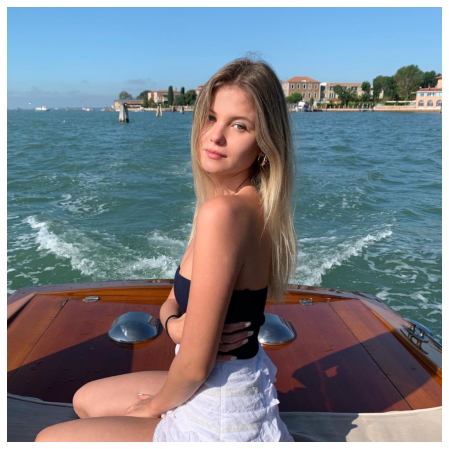

In [2]:
image = io.imread('demo.jpg')
image_tensor = torch.from_numpy(image)
plt.figure(figsize=(8, 8))
plt.imshow(image)
plt.axis('off')

In [3]:
randerase = RandomErasing(probability=0.9, min_area=0.1, max_area=0.3, mode='rand', device='cpu', cube=False)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


(-0.5, 1079.5, 1079.5, -0.5)

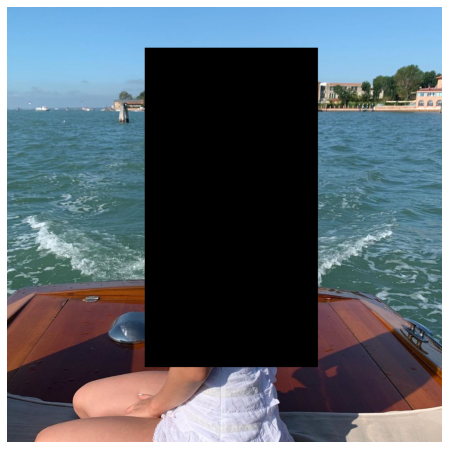

In [4]:
image_erase = randerase(image_tensor.permute(2, 0, 1)/255.)

plt.figure(figsize=(8, 8))
plt.imshow(image_erase.permute(1, 2, 0).numpy())
plt.axis('off')

In [5]:
from imgaug import augmenters as iaa
import imgaug as ia

ia.seed(42)

In [6]:
rand_aug = iaa.RandAugment(n=3, m=7)

In [7]:
def augment(image):
    return rand_aug(image=image)

In [8]:
image_aug = augment(image)

(-0.5, 1079.5, 1079.5, -0.5)

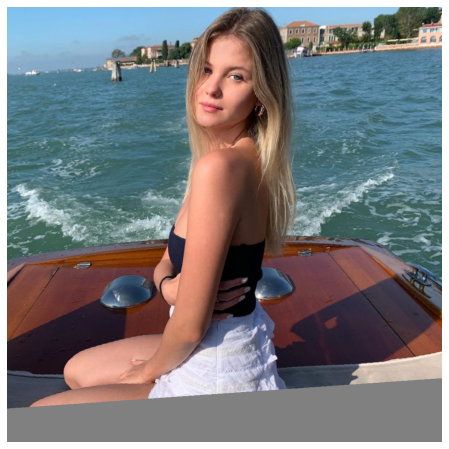

In [9]:
plt.figure(figsize=(8, 8))
plt.imshow(image_aug)
plt.axis('off')

In [10]:
from sesame.datasets.transform import create_random_augment

In [11]:
image_tensor = image_tensor.permute(2, 0, 1)

In [12]:
aug_transform = create_random_augment(
    input_size=(image_tensor.size(1), image_tensor.size(2)),
    auto_augment="rand-m7-n4-mstd0.5-inc1",
    interpolation="bicubic",
)

In [13]:
list_img = [transforms.ToPILImage()(image_tensor)]
list_img = aug_transform(list_img)

In [14]:
img_aug = transforms.ToTensor()(list_img[0])

In [17]:
img_aug = img_aug.permute(1, 2, 0)

In [ ]:
plt.figure(figsize=(8, 8))
plt.imshow(img_aug.numpy())
plt.axis('off')